# 12.4.2 딥 큐-러닝

- 합성곱 신경망을 이용해 큐-함수를 학습하는 강화학습기법
- Goal : 합성곱층을 깊게 해 훈련 시 큐값의 정확도 ⬆

 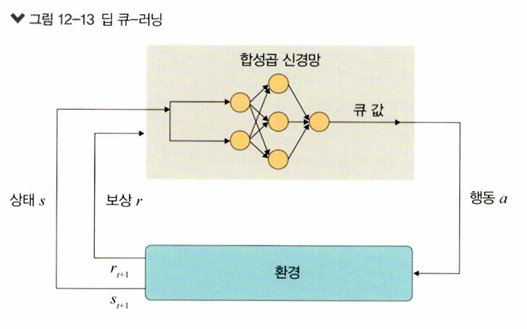

## 딥 큐러닝의 특징들

1. 강화학습을 위한 시뮬레이션 환경 제공
2. 타깃 큐-네트워크
3. 리플레이 메모리
4. 합성곱 신경망을 활용한 큐-함수



### 📌 강화 학습을 위한 시뮬레이션 환경 제공

- 강화 학습은 주로 게임에서 사용

- reset( ) 함수 : 환경  초기화
  - 에이전트가 게임 시작 시/초기화 요구 시 사용
  - 초기화될 때는 관찰 변수 반환

- step( ) 함수 : 에이전트에 명령을 내리는 함수
  - 가장 많이 호출되는 함수
  - 이 함수로 행동 명령을 보내고 환경에서 관찰 변수, 보상 및 게임 종료 여부 등 변수 반환

- render( ) 함수 : 화면에 상태 표시

### 📌 타깃-큐 네트워크
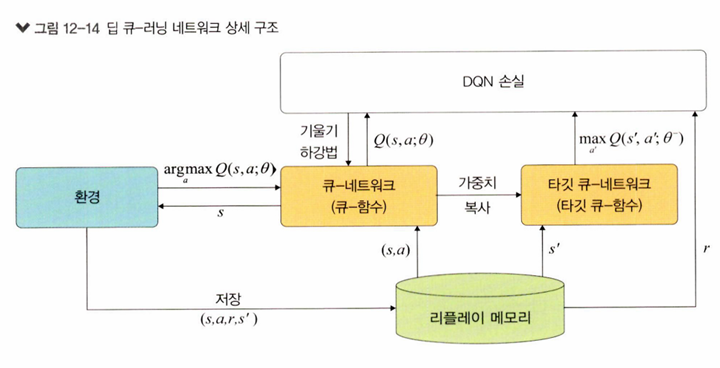

- 기존 큐-러닝의 문제점
  - 큐 함수가 학습되면서 큐 값이 계속 바뀜
  - -> 이를 해결하기 위해 타깃-큐 네트워크도 큐 네트워크와 같이 사용
- 타깃 큐 네트워크, 큐 네트워크는 가중치 파라미터만 다르고 동일
- DQN : 수렴 원활히 하기 위해 타깃 큐-네트워크를 주기적으로 한번씩 업데이트
- 학습 시 손실함수 : MSE

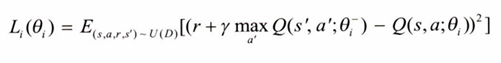

### 📌 리플레이 메모리

- 에이전트가 수집한 데이터를 저장하는 저장소
  - 큐 러닝 : 데이터 간의 상관관계로 학습 속도 ⬇
  - 딥 큐-러닝 : 리플레이 메모리 도입을 통해 학습 속도 해결
- 에이전트 상태가 변경돼도 즉시 훈련 ❌, 일정 수 데이터 수집까지 대기
- 버퍼에 일정 수의 메모리가 쌓이면 랜덤 데이터 추출 + 미니 배치 활용 학습
- 하나의 데이터 : $$e_t = (s_t, a_t, r_t, s_{t+1} )$$
  - 상태, 행동, 보상, 다음 상태 저장됨.

### 합성곱 신경망을 활용한 큐-함수

- OpenAI Gym의 CartPole 이용
  - CartPole-v1의 에이전트는 카트에 부착된 막대기가 수직 상태를 유지할 수 있게 카트를 왼/오로 이동(중심을 찾기 위해 지속적으로 이동)
  
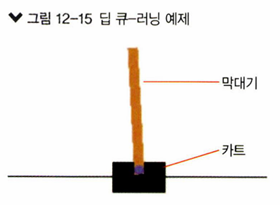
- 에이전트 : 현재 상태 관찰 -> 왼/오로 이동 -> 환경은 새로운 상태로 전이됨 -> 행동의 결과로 보상(+1) 획득

- CartPole의 상태 : 위치(왼쪽, 오른쪽), 속도, 가속도
- 에이전트 행동 : 왼쪽, 오른쪽
- 보상 : 각 행동마다 +1

In [1]:
# gym - 강화학습환경 구성 도움 패키지
!pip install gym

### 코드 12-1 라이브러리 호출

In [1]:
!pip uninstall -y gym gymnasium numpy
!pip install -q numpy==1.26.4 gymnasium[classic-control]

Found existing installation: gym 0.25.2
Uninstalling gym-0.25.2:
  Successfully uninstalled gym-0.25.2
Found existing installation: gymnasium 1.2.3
Uninstalling gymnasium-1.2.3:
  Successfully uninstalled gymnasium-1.2.3
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 58.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, which is not installed.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", b

- 패키지 호환 문제로 gym이 아니라 gymnasium 사용

In [1]:
import numpy as np
import gymnasium as gym

print(np.__version__)

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = env.reset()

frame = env.render()
print(type(frame))
print(frame.shape)

1.26.4
<class 'numpy.ndarray'>
(400, 600, 3)


In [3]:
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# namedtuple - 튜플에 담긴 요소들의 인덱스와 값으로 모두 접근 가능
from collections import namedtuple
# count - 무한 루프 사용을 위한 라이브러리
from itertools import count
# Image - 이미지 처리를 위한 라이브러리
from PIL import Image


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T

env = gym.make('CartPole-v1',render_mode='rgb_array').unwrapped
plt.ion()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 코드 12-2 한글 깨짐 방지

In [4]:
'''
from matplotlib import font_manager
# 경로 변경 없이 그대로 사용
font_fname = './malgun.ttf'
font_family = font_manager.FontProperties(fname=font_fname).get_name()
plt.rcParams["font.family"] = font_family
'''

'\nfrom matplotlib import font_manager\n# 경로 변경 없이 그대로 사용\nfont_fname = \'./malgun.ttf\'\nfont_family = font_manager.FontProperties(fname=font_fname).get_name()\nplt.rcParams["font.family"] = font_family\n'

- 코랩 환경은 아래 셀에서 테스트

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

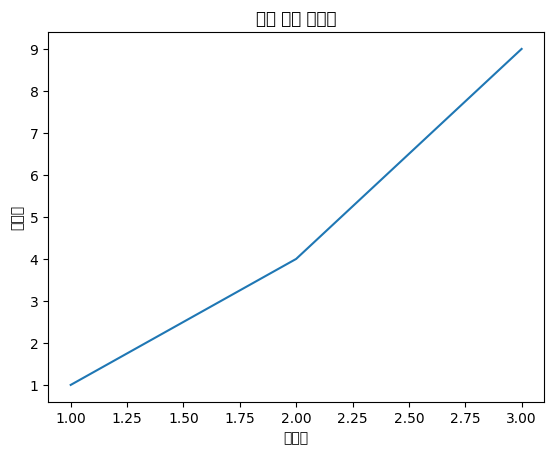

In [5]:
'''
!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv
'''
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.plot([1, 2, 3], [1, 4, 9])
plt.title('한글 제목 테스트')
plt.xlabel('가로축')
plt.ylabel('세로축')
plt.show()

### 코드 12-3 리플레이 메모리


In [6]:
# 상태 전이와 관련된 정보 저장
## 현재 상태와 행동은 다음 상태와 보상으로 매핑
Transition = namedtuple('Transition',
                        ('state','action','next_state','reward'))

# 리플레이 메모리(버퍼)에는 최근 관찰ㄹ된 전이, 현재 상태, 행동, 다음 상태, 보상정보 저장
class ReplayMemory(object):
  def __init__(self, capacity):
    self.capacity = capacity
    self.memory = []
    self.position = 0

  def push(self, *args):
    if len(self.memory) < self.capacity:
      self.memory.append(None)
    self.memory[self.position] = Transition(*args)
    self.position = ( self.position +1 ) % self.capacity

  def sample(self, batch_size):
    # sample 메서드 : 리플레이 메모리에 저장된 데이터 중 랜덤하게 배치 크기만큼 반환
    return random.sample(self.memory, batch_size)

  def __len__(self):
    return len(self.memory)

### 코드 12-4 DQN 모델 네트워크

In [7]:
class DQN(nn.Module):
  def __init__(self, h, w, outputs):
    super(DQN, self).__init__()
    self.conv1 = nn.Conv2d(3,16,kernel_size=5, stride=2)
    self.bn1 = nn.BatchNorm2d(16)
    self.conv2 = nn.Conv2d(16,32,kernel_size=5, stride=2)
    self.bn2 = nn.BatchNorm2d(32)
    self.conv3 = nn.Conv2d(32,32,kernel_size=5, stride=2)
    self.bn3 = nn.BatchNorm2d(32)

    def conv2d_size_out(size, kernel_size=5, stride=2):
      return (size - (kernel_size-1)-1)//stride + 1

    convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(w)))
    convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(h)))
    # 선형 계층의 입력은 합성곱층(Conv2d)의 출력, 입력 이미지 크기에 따라 달라짐
    linear_input_size = convw * convh * 32
    self.head = nn.Linear(linear_input_size, outputs)

  def forward(self, x):
    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = F.relu(self.bn3(self.conv3(x)))
    # 함수의 반환값은 [[left0exp, right0exp] ··· ]와 같으며 다음 행동을 결정하기 위해 사용
    return self.head(x.view(x.size(0),-1))

### 코드 12-5 이미지 추출 및 처리

In [9]:
# pyglet 패키지 설치
!pip install pyglet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


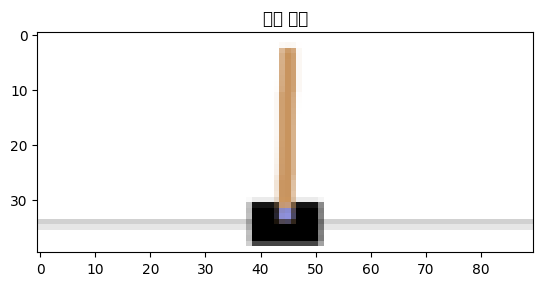

In [10]:
import pyglet
# 이미지 크기 및 텐서 변환
resize = T.Compose([T.ToPILImage(),
                    T.Resize(40, interpolation=Image.Resampling.BICUBIC), #CUBIC > BICUBIC
                    T.ToTensor()])

# 카트의 위치 정보 가져오기
def get_cart_location(screen_width):
  world_width = env.x_threshold * 2
  scale = screen_width / world_width
  ## 카트의 중간(중앙) 위치 리턴
  return int(env.state[0] * scale + screen_width/2.0)

# 앱실론 욕심쟁이 정책에 따라 행동 선택
## 행동 선택 -> 활용, 탐험 방법 이용
## 모델 활용 / 리플레이 메모리의 데이터를 랜덤하게 샘플링해 탐ㅎ머
### 랜덤 샘플링을 선택할 확률 - EPS_START에서 시작해 EPS_END를 향해 기하급수적으로 감소
### EPS_DECAY : 깜소하는 비율 제어
def get_screen():
  # gym을 이용한 출력은 400x600x3의 형태를 갖지만
  # 때로는 800x1200x3 형태 가짐. -> 이 때는 데이터형을 (채널,높이,너비)로 변경
  screen = env.render().transpose((2,0,1))
  _, screen_height, screen_width = screen.shape
  screen = screen[:, int(screen_height*0.4):int(screen_height*0.8)]
  view_width = int(screen_width*0.6)
  cart_location = get_cart_location(screen_width)

  # 카트는 출력 화면의 아래쪽 중앙에 존재하므로 화면의 위쪽과 아래쪽을 제거
  if cart_location < view_width//2:
    # slice는 데이터 중 일부를 잘라서 가져올 때 사용
    slice_range = slice(view_width)
  elif cart_location > (screen_width - view_width//2):
    slice_range = slice(-view_width,None)
  else:
    slice_range = slice(cart_location - view_width//2,
                        cart_location + view_width//2)
  # 카트가 화면의 중앙에 위치하도록 가장자리 제거
  screen = screen[:, :, slice_range]
  # 데이터 실수로 변환 ,출력 크기 조정
  # np.ascontiguousarray(screen, dtype) : 메모리에서 연속적인 배열을 반환하고자 할 때 사용
  ## screen - 변환될 데이터(입력 데이터), dtype : 반한되는 데이터 타입
  screen = np.ascontiguousarray(screen, dtype = np.float32)/255
  screen = torch.from_numpy(screen)
  return resize(screen).unsqueeze(0).to(device)
# 환경 초기화
env.reset()
plt.figure()
# permute 함수는 transpose 함수처럼 차원을 바꾸어서 표현할 때 사용
plt.imshow(get_screen().cpu().squeeze(0).permute(1,2,0).numpy(),
           interpolation='none')
plt.title('화면 예시')
plt.show()

### 코드 12-6 모델 객체화 및 손실함수 정의

In [11]:
BATCH_SIZE = 128
GAMMA = 0.999
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 200
TARGET_UPDATE = 10

init_screen = get_screen()
# gym의 출력 모양에 따라 네트워크 계층 올바르게 초기화
# 화면 크기 - 3x40x90에 가까운데 get_screen()에서 압축/축소
# get_screen()함수에서 env.render()를 통해 화면 크기 정보 가져옴
# slice() 적용해 크기 축소
_, _, screen_height, screen_width = init_screen.shape
n_actions = env.action_space.n ## gym에서 행동 횟수 가져오기

policy_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net = DQN(screen_height, screen_width, n_actions).to(device)
# load_state_dict : state_dict 값을 읽고 모델의 파라미터 값 채워줌
## state_dict : 모델 저장/업뎃/변경/복원 위해 사용
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.RMSprop(policy_net.parameters())
memory = ReplayMemory(10000)

steps_done = 0

def select_action(state):
  global steps_done
  sample = random.random()
  eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1.*steps_done / EPS_DECAY)
  steps_done += 1
  if sample > eps_threshold:
    with torch.no_grad():
      return policy_net(state).max(1)[1].view(1,1) # max(1)는 각 행의 가장 큰 열 값 반환

  else:
    return torch.tensor([[random.randrange(n_actions)]],
                        device=device,dtype=torch.long)

episode_durations = []

### 12-7 모델에서 사용할 옵티마이저 정의

- 모델 학습 과정
1. 리플레이 메모리에서 샘플 데이터(텐서) 가져옴
2. `torch.cat` 이용해 하나의 텐서로 연결
3. $$Q(s_t,a_t)\quad 및\quad V(s_{t+1})$$ 계산, 손실함수에서 사용
  - s가 최종상태(종료)이면 $$V(s)=0$$으로 설정
4. 알고리즘의 안정성을 높이기 위해 타깃 네트워크(`target_net`)을 사용해 $$V(S_{t+1})$$계산
5. 타깃 네트워크의 가중치는 일정 시간 동안 고정된 상태로 유지, 정기적으로 정책 네트워크의 가중치로 업데이트

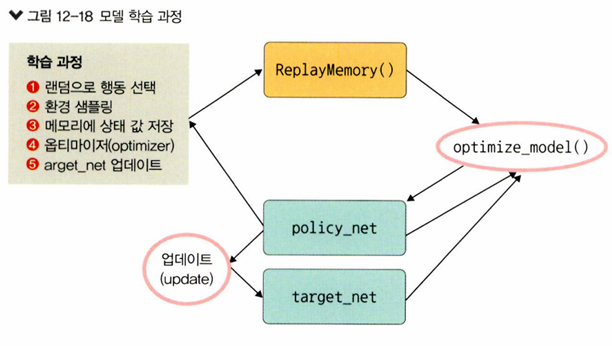

- 사용 손실 함수 : smooth_l1_loss

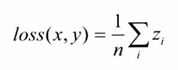
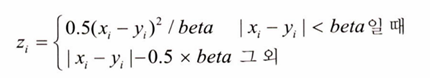

In [12]:
# replay memory에서 무작위 데이터 선택, 새로운 정책 학습
# 최신 상태를 유지하기 위해 target_net에 가중치/편향 업데이트
def optimize_model():
  if len(memory) < BATCH_SIZE:
      return

  transitions = memory.sample(BATCH_SIZE)
  batch = Transition(*zip(*transitions)) # zip - transpose 역할
  # 게임의 상태 계산 - torch.cat으로 s값들 이어 붙임.
  ## map : 여러개의 데이터를 한번에 다른 형태로 변환할 때 사용
  non_final_mask = torch.tensor(tuple(map(lambda s : s is not None,
                                           batch.next_state)), device=device, dtype = torch.bool)
  non_final_next_states = torch.cat([s for s in batch.next_state
                                     if s is not None])
  state_batch = torch.cat(batch.state)
  action_batch = torch.cat(batch.action)
  reward_batch = torch.cat(batch.reward)

  ## Q(S_t, a_t) 계산
  state_action_values = policy_net(state_batch).gather(1, action_batch)
  next_state_values = torch.zeros(BATCH_SIZE, device=device)
  # 발생가능한 다음 상태 계산 위한 코드
  ## 다음 상태 발생할 행동 기댓값 계산 - 타깃네트워크 사용
  ## 다음상태 행동은 보상이 최대(max(1)[0]) 되는 것 선택
  next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0].detach()
  ## V(S_{t+1})
  expected_state_action_values = (next_state_values * GAMMA) + reward_batch
  # 오차 계산 - smooth_l1_loss(Q(s_t,a_t), v(s_{t+1}) : L1, L2 손실 함께 사용
  ### 배열에서 요소별 오차의 절댓값이 베타 미만 : L2, 베타 이상 : L1
  ### L2 : U자, 미분 가능, 이상치 취약  L1 : V자, 미분불가, 이상치 강함
  loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))
  optimizer.zero_grad()
  loss.backward()

  for param in policy_net.parameters():
    param.grad.data.clamp_(-1,1)
  optimizer.step()

### 코드 12-8 모델 학습

In [13]:
num_episodes = 50

for i_episode in range(num_episodes):
  env.reset() # 환경, 상태 초기화
  last_screen = get_screen()
  current_screen = get_screen()
  state = current_screen - last_screen

  for t in count():
    # 행동 선택 및 실행
    action = select_action(state)
    # 선택한 행동을 환경으로 전송
    next_state, reward, done, _, _ = env.step(action.item())
    reward = torch.tensor([reward],device = device)

    last_screen = current_screen
    current_screen = get_screen()

    if not done: # 새로운 상태 관찰
      next_state = current_screen - last_screen
    else:
      next_state = None

    # 상태 전이를 메모리에 저장
    memory.push(state, action,next_state,reward)
    # 다음 상태로 이동
    state = next_state
    # 타깃(큐) 네트워크에 대해 최적화 진행
    optimize_model()
    if done:
      episode_durations.append(t+1)
      break

  if i_episode % TARGET_UPDATE == 0:
    # 큐 네트워크의 모든 가중치, 바이어스 복사 -> 타깃 네트워크 업데이트
    target_net.load_state_dict(policy_net.state_dict())

print('종료')
# 화면 출력
env.render()
# 화면 종료
env.close()
plt.show()

종료
